# 전자부품(배터리팩) 예지보전 AI 데이터셋 — EDA

`00_가이드북_요약.ipynb`에서 정리한 내용을 바탕으로, 실제 데이터를 로드하여 구조와 특성을 탐색합니다.

- 학습 데이터: `Training_Data.csv` (정상 데이터)
- 테스트 데이터: `WeldingTest_01_OK.csv`, `WeldingTest_02_OK.csv` (정상) /
  `WeldingTest_03_NG.csv`(고립형 이상), `WeldingTest_04_NG.csv`(연속형 이상)
- 라벨: `WeldingTest_03_NG_Label.csv`, `WeldingTest_04_NG_Label.csv` (이상 구간 1/0 라벨)

본 노트북은 `notebooks/` 폴더에서 실행하는 것을 기준으로 상대경로(`../data/...`)를 사용합니다.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DATA_DIR = "../data"
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
# 한글 폰트 설정 (그래프의 한글 라벨이 깨지지 않도록 OS별 폰트를 자동 탐색)
import matplotlib.font_manager as fm

_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR",
               "Noto Sans CJK JP", "Noto Sans CJK SC", "Noto Sans CJK TC"]
_available = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _candidates if f in _available), None)

if _font:
    plt.rcParams["font.family"] = _font
else:
    print("경고: 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨져 보일 수 있습니다. "
          "(예: NanumGothic 설치 필요 - Linux: apt-get install fonts-nanum)")

plt.rcParams["axes.unicode_minus"] = False

## 1. 데이터 로드

In [3]:
paths = {
    "train": f"{DATA_DIR}/raw_data/train/Training_Data.csv",
    "test01_OK": f"{DATA_DIR}/raw_data/test/WeldingTest_01_OK.csv",
    "test02_OK": f"{DATA_DIR}/raw_data/test/WeldingTest_02_OK.csv",
    "test03_NG": f"{DATA_DIR}/raw_data/test/WeldingTest_03_NG.csv",
    "test04_NG": f"{DATA_DIR}/raw_data/test/WeldingTest_04_NG.csv",
}
label_paths = {
    "test03_NG": f"{DATA_DIR}/preprocessed/test/WeldingTest_03_NG_Label.csv",
    "test04_NG": f"{DATA_DIR}/preprocessed/test/WeldingTest_04_NG_Label.csv",
}

def load_clean(path):
    """CSV 로드 + 컬럼명 공백 제거 (가이드북 [코드 7] 참고)"""
    df = pd.read_csv(path)
    df = df.rename(columns=lambda c: c.strip())
    return df

datasets = {name: load_clean(p) for name, p in paths.items()}
labels = {name: pd.read_csv(p) for name, p in label_paths.items()}

for name, df in datasets.items():
    print(f"{name:12s} shape={df.shape}")

train        shape=(135759, 9)
test01_OK    shape=(1950, 9)
test02_OK    shape=(1872, 9)
test03_NG    shape=(1053, 9)
test04_NG    shape=(351, 9)


## 2. 데이터 구조 확인 (학습 데이터 기준)

In [4]:
train = datasets["train"]
train.head()

,PageNo,Speed,Length,RealPower,SetFrequency,SetDuty,SetPower,GateOnTime,WorkingTime
0,1,250,241.1,1688,1000,100,82,1154,2022-01-08 10:11:45.181
1,2,250,241.2,1713,1000,100,83,1670,2022-01-08 10:11:48.487
2,3,250,241.1,1695,1000,100,82,1153,2022-01-08 10:11:51.245
3,4,250,241.2,1717,1000,100,83,1670,2022-01-08 10:11:54.493
4,5,250,241.1,1698,1000,100,82,1154,2022-01-08 10:11:57.269


In [5]:
print("컬럼:", list(train.columns))
train.info()

컬럼: ['PageNo', 'Speed', 'Length', 'RealPower', 'SetFrequency', 'SetDuty', 'SetPower', 'GateOnTime', 'WorkingTime']
<class 'pandas.DataFrame'>
RangeIndex: 135759 entries, 0 to 135758
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   PageNo        135759 non-null  int64  
 1   Speed         135759 non-null  int64  
 2   Length        135759 non-null  float64
 3   RealPower     135759 non-null  int64  
 4   SetFrequency  135759 non-null  int64  
 5   SetDuty       135759 non-null  int64  
 6   SetPower      135759 non-null  int64  
 7   GateOnTime    135759 non-null  int64  
 8   WorkingTime   135759 non-null  str    
dtypes: float64(1), int64(7), str(1)
memory usage: 9.3 MB


In [6]:
train.describe()

,PageNo,Speed,Length,RealPower,SetFrequency,SetDuty,SetPower,GateOnTime
count,135759.00000,135759.000000,135759.000000,135759.000000,135759.0,135759.0,135759.000000,135759.000000
mean,20.00000,165.013811,155.534759,1310.510780,1000.0,100.0,65.384615,1117.989651
std,11.25467,106.977945,107.806431,493.224711,0.0,0.0,21.653072,421.956610
min,1.00000,30.000000,19.400000,0.000000,1000.0,100.0,38.000000,650.000000
25%,10.00000,30.000000,19.400000,688.000000,1000.0,100.0,38.000000,650.000000
50%,20.00000,250.000000,241.100000,1688.000000,1000.0,100.0,82.000000,1154.000000
75%,30.00000,250.000000,241.200000,1704.000000,1000.0,100.0,83.000000,1670.000000
max,39.00000,250.000000,241.200000,1733.000000,1000.0,100.0,83.000000,1670.000000


## 3. 데이터 품질 점검

가이드북에서 안내한 대로 결측치, 단일값(상수) 컬럼, 이상치를 점검합니다.


In [7]:
# 결측치 확인
missing = train.isna().sum()
print("결측치 개수:")
print(missing)
print("\n완전성 품질지수: {:.2f}%".format(100 * (1 - missing.sum() / train.size)))

결측치 개수:
PageNo          0
Speed           0
Length          0
RealPower       0
SetFrequency    0
SetDuty         0
SetPower        0
GateOnTime      0
WorkingTime     0
dtype: int64

완전성 품질지수: 100.00%


In [8]:
# 단일값(상수)만 갖는 컬럼 확인 -> 가이드북에서는 SetFrequency, SetDuty가 여기 해당
nunique = train.nunique()
print(nunique)
constant_cols = nunique[nunique <= 1].index.tolist()
print("\n상수 컬럼:", constant_cols)

PageNo              39
Speed                6
Length               4
RealPower           71
SetFrequency         1
SetDuty              1
SetPower             3
GateOnTime           9
WorkingTime     135759
dtype: int64

상수 컬럼: ['SetFrequency', 'SetDuty']


In [9]:
# 분석에 사용할 수치형 컬럼 (상수 컬럼 및 시간 컬럼 제외)
numeric_cols = [c for c in train.columns if c not in constant_cols + ["WorkingTime"]]
print("분석 대상 수치형 컬럼:", numeric_cols)

분석 대상 수치형 컬럼: ['PageNo', 'Speed', 'Length', 'RealPower', 'SetPower', 'GateOnTime']


In [10]:
# IQR 기반 이상치 탐지 (가이드북 [코드 26]~[코드 29], c=4.0)
def identify_outliers(df, c=4.0):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    mask = ((df.lt(Q1 - c * IQR)) | (df.gt(Q3 + c * IQR))).any(axis=1)
    return df[mask]

outliers = identify_outliers(train[numeric_cols], c=4.0)
print(f"이상치로 탐지된 행 수: {len(outliers)} / 전체 {len(train)}")

이상치로 탐지된 행 수: 0 / 전체 135759


## 4. 주요 변수 분포 (히스토그램)

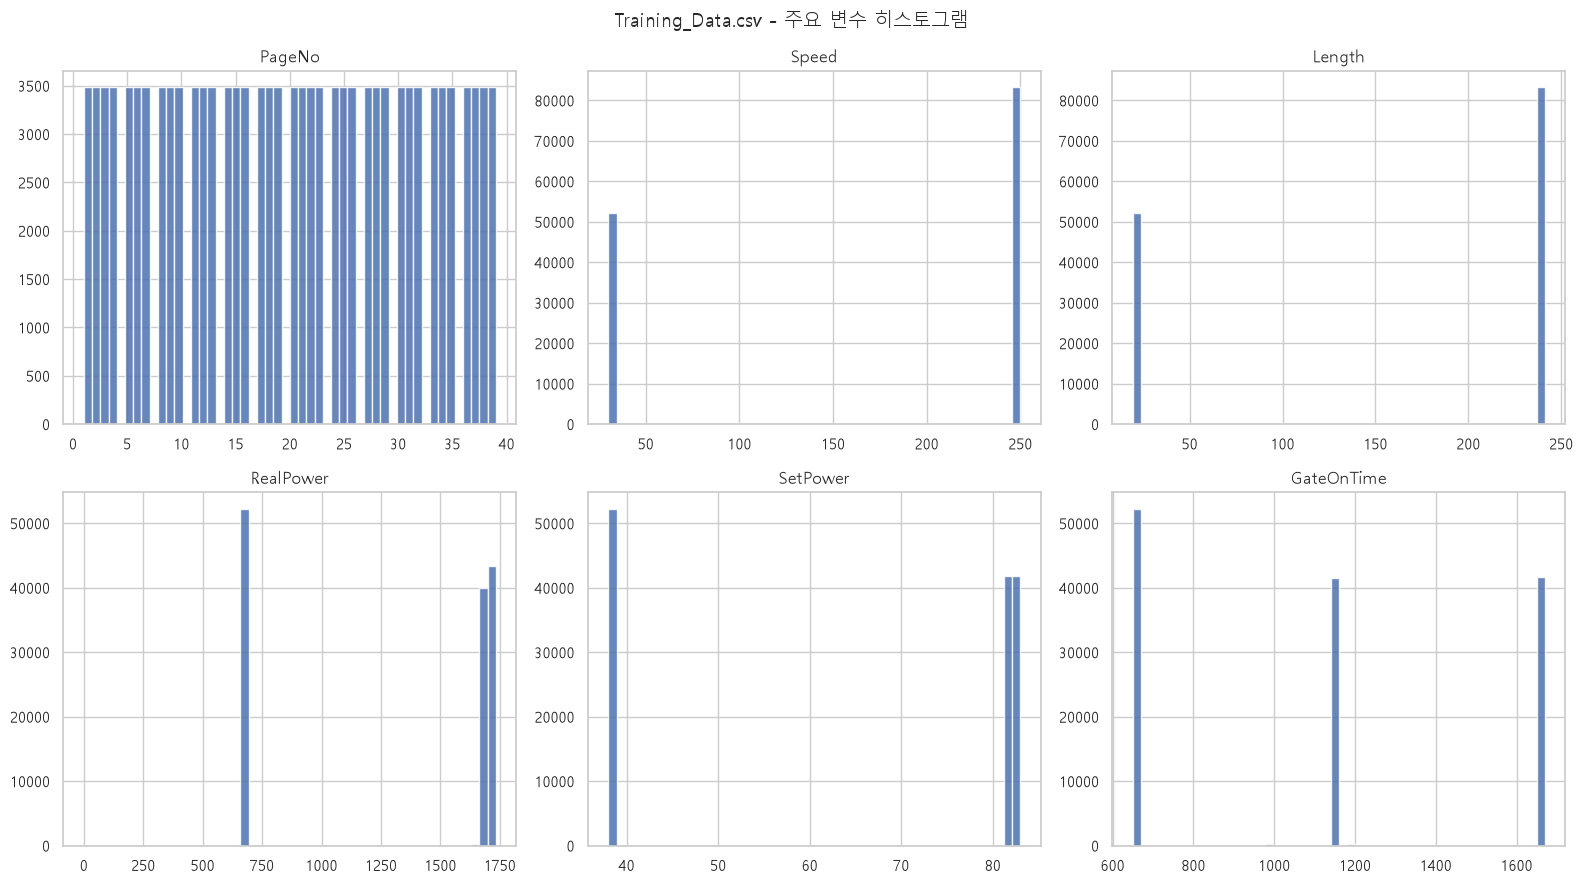

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(train[col], bins=50, color="#4C72B0", alpha=0.85)
    ax.set_title(col)
fig.suptitle("Training_Data.csv - 주요 변수 히스토그램", fontsize=14)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/train_histograms.png", dpi=120)
plt.show()

## 5. RealPower 시계열 및 SetPower 별 분포

가이드북 설명에 따르면 RealPower는 SetPower(38%, 82%, 83%)에 따라 대략 `2000 × SetPower`
근처 값을 가지는 주기적 거동을 보입니다.


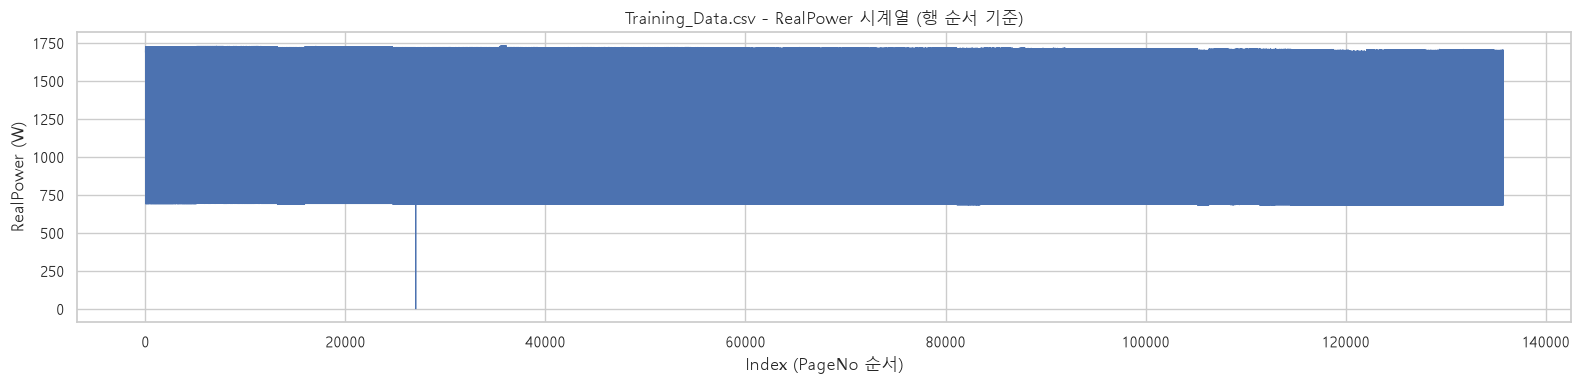

In [12]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(train["RealPower"].values, linewidth=0.6, color="#4C72B0")
ax.set_title("Training_Data.csv - RealPower 시계열 (행 순서 기준)")
ax.set_xlabel("Index (PageNo 순서)")
ax.set_ylabel("RealPower (W)")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/train_realpower_timeseries.png", dpi=120)
plt.show()

SetPower 고유값: [np.int64(38), np.int64(82), np.int64(83)]


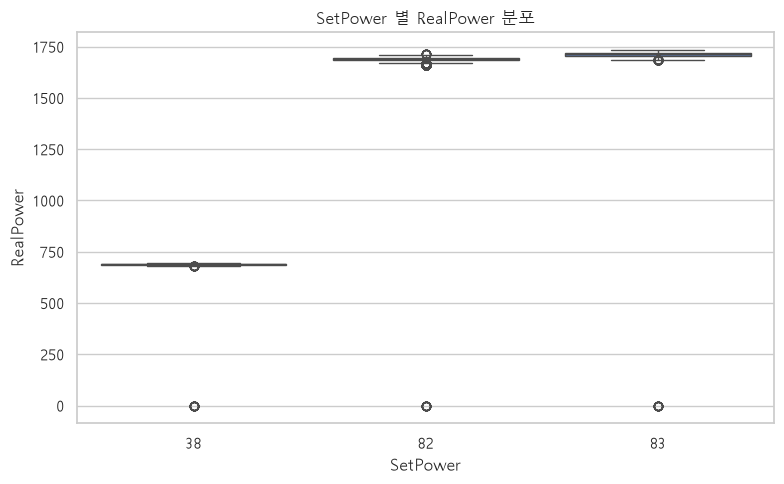

In [13]:
print("SetPower 고유값:", sorted(train["SetPower"].unique()))

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=train, x="SetPower", y="RealPower", ax=ax)
ax.set_title("SetPower 별 RealPower 분포")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/realpower_by_setpower.png", dpi=120)
plt.show()

## 6. 변수 간 상관관계

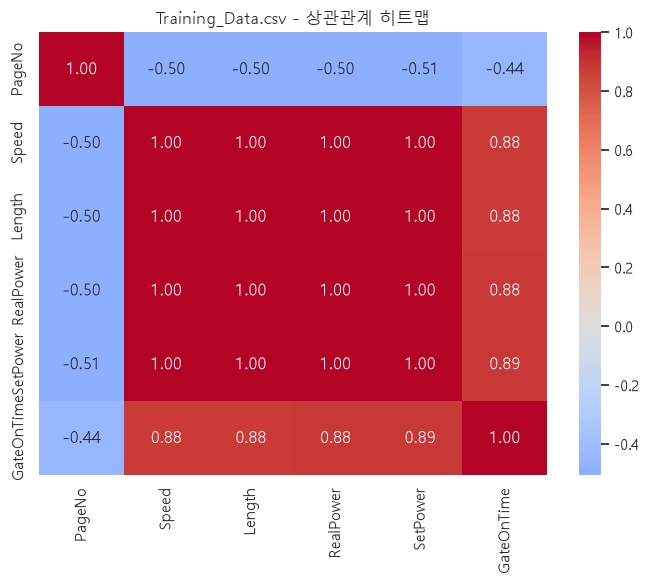

In [14]:
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Training_Data.csv - 상관관계 히트맵")
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/train_correlation_heatmap.png", dpi=120)
plt.show()

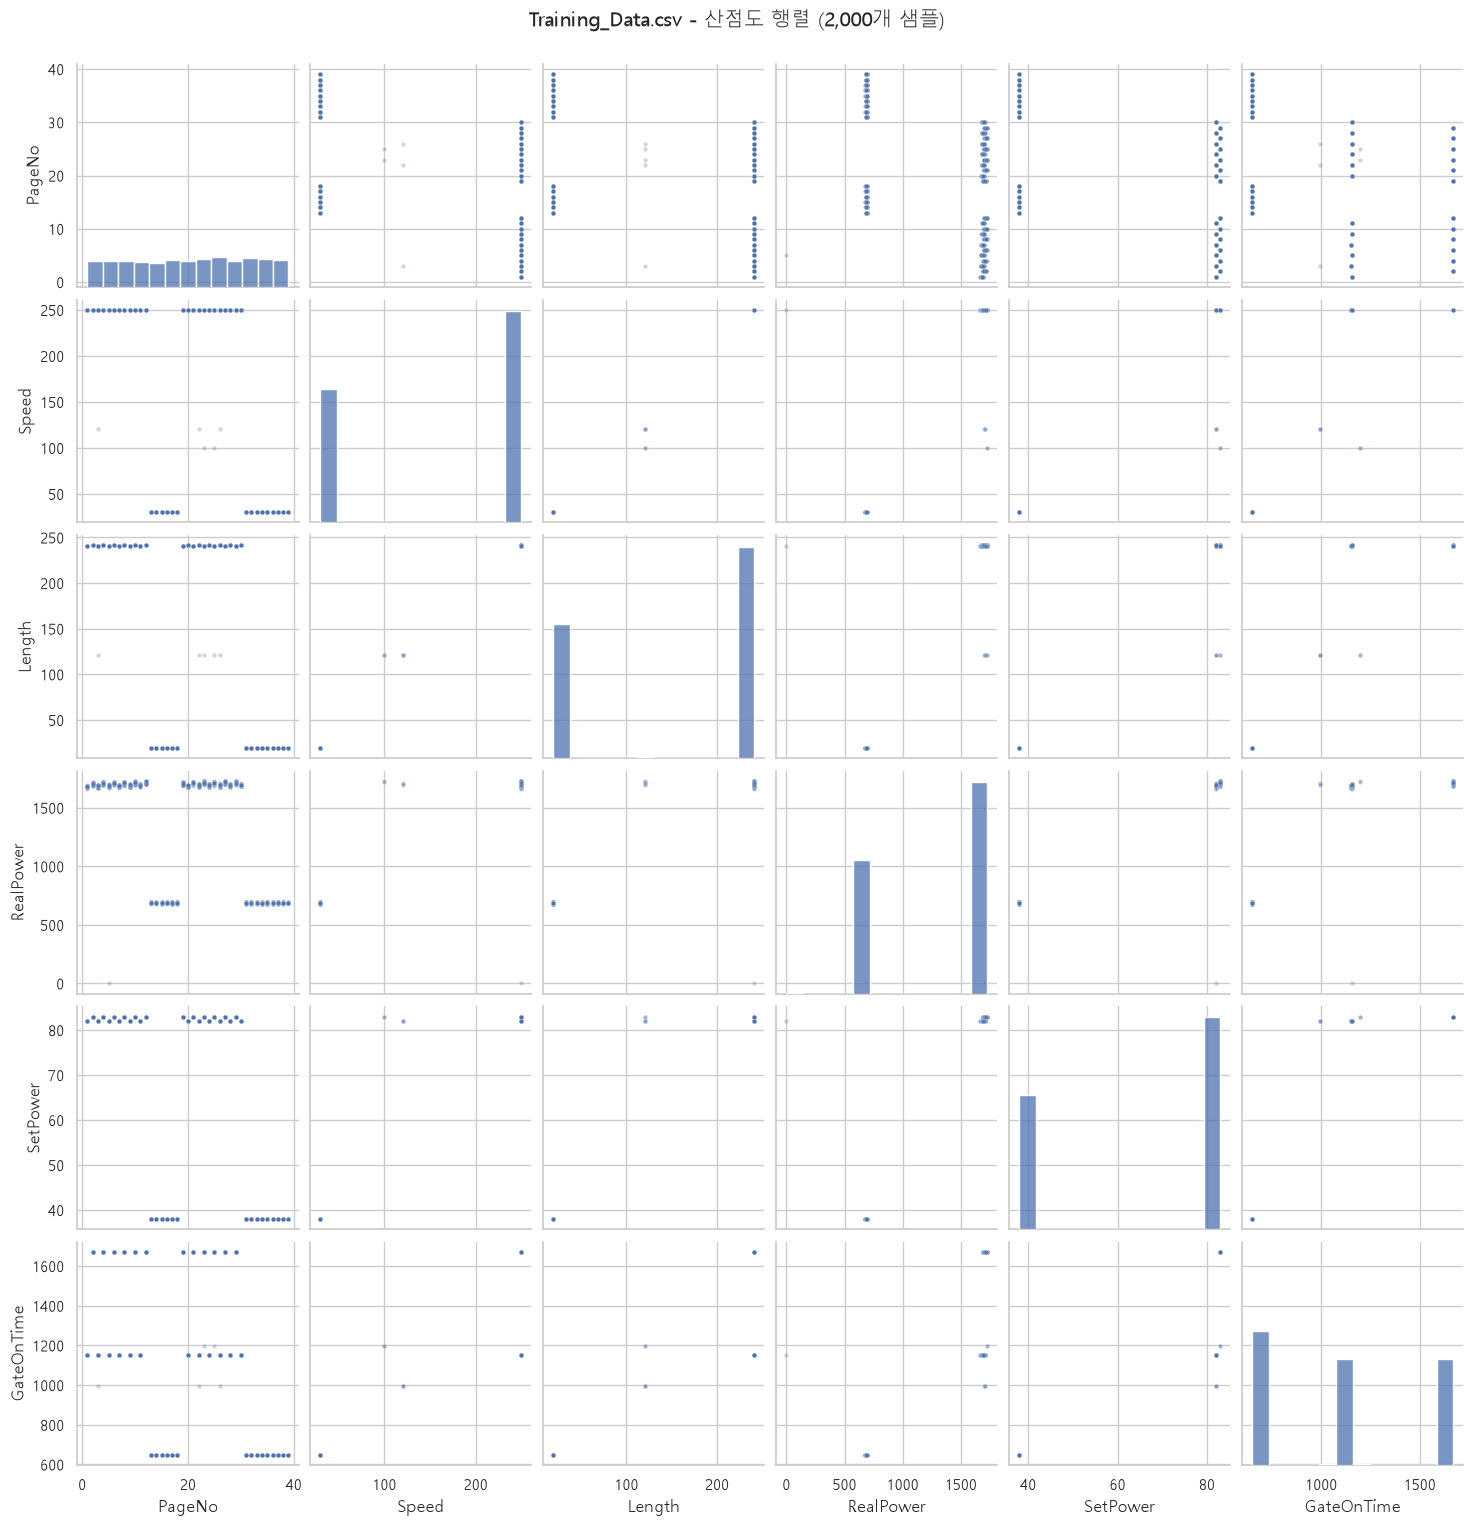

In [15]:
sns.pairplot(train[numeric_cols].sample(min(2000, len(train)), random_state=42),
             diag_kind="hist", plot_kws={"alpha": 0.3, "s": 10})
plt.suptitle("Training_Data.csv - 산점도 행렬 (2,000개 샘플)", y=1.02)
plt.savefig(f"{OUTPUT_DIR}/train_pairplot.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. 정상(OK) vs 비정상(NG) 테스트 데이터 비교

학습 데이터와 4개 테스트 데이터셋의 RealPower 기술통계를 비교합니다.


In [16]:
summary_rows = []
for name, df in datasets.items():
    s = df["RealPower"].describe()
    s["dataset"] = name
    summary_rows.append(s)

realpower_summary = pd.DataFrame(summary_rows).set_index("dataset")
realpower_summary

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
train,135759.0,1310.510780,493.224711,0.0,688.0,1688.0,1704.0,1733.0
test01_OK,1950.0,1300.518462,488.794838,682.0,683.0,1675.0,1693.0,1704.0
test02_OK,1872.0,1299.246795,488.389311,680.0,682.0,1674.0,1692.0,1702.0
test03_NG,1053.0,1297.564103,489.288397,630.0,682.0,1673.0,1690.0,1702.0
test04_NG,351.0,819.569801,610.576837,0.0,127.0,1201.0,1227.0,1727.0


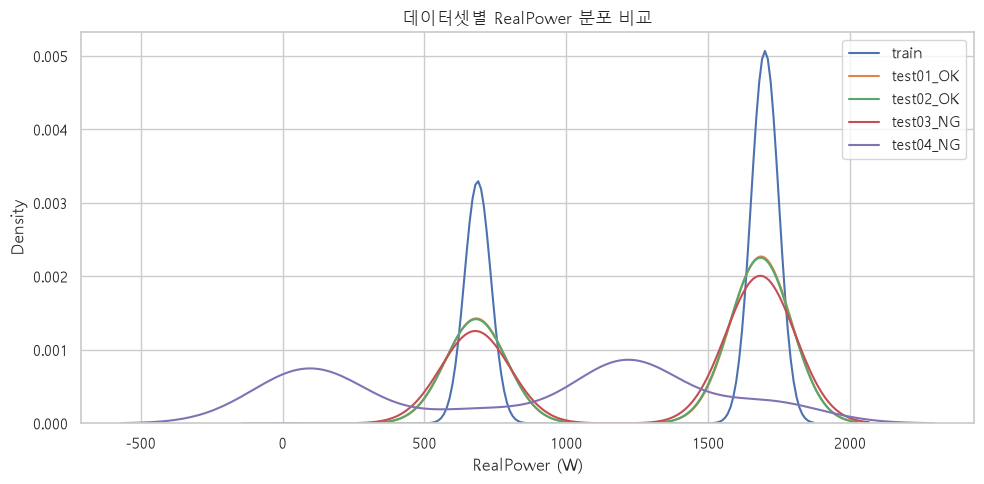

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, df in datasets.items():
    sns.kdeplot(df["RealPower"], label=name, ax=ax, linewidth=1.5)
ax.set_title("데이터셋별 RealPower 분포 비교")
ax.set_xlabel("RealPower (W)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/realpower_distribution_by_dataset.png", dpi=120)
plt.show()

## 8. 이상 구간(Label) 시각화

`WeldingTest_03_NG.csv`(고립형 이상)와 `WeldingTest_04_NG.csv`(연속형 이상)의 RealPower 시계열 위에
실제 이상 라벨(`label==1`) 구간을 표시합니다.


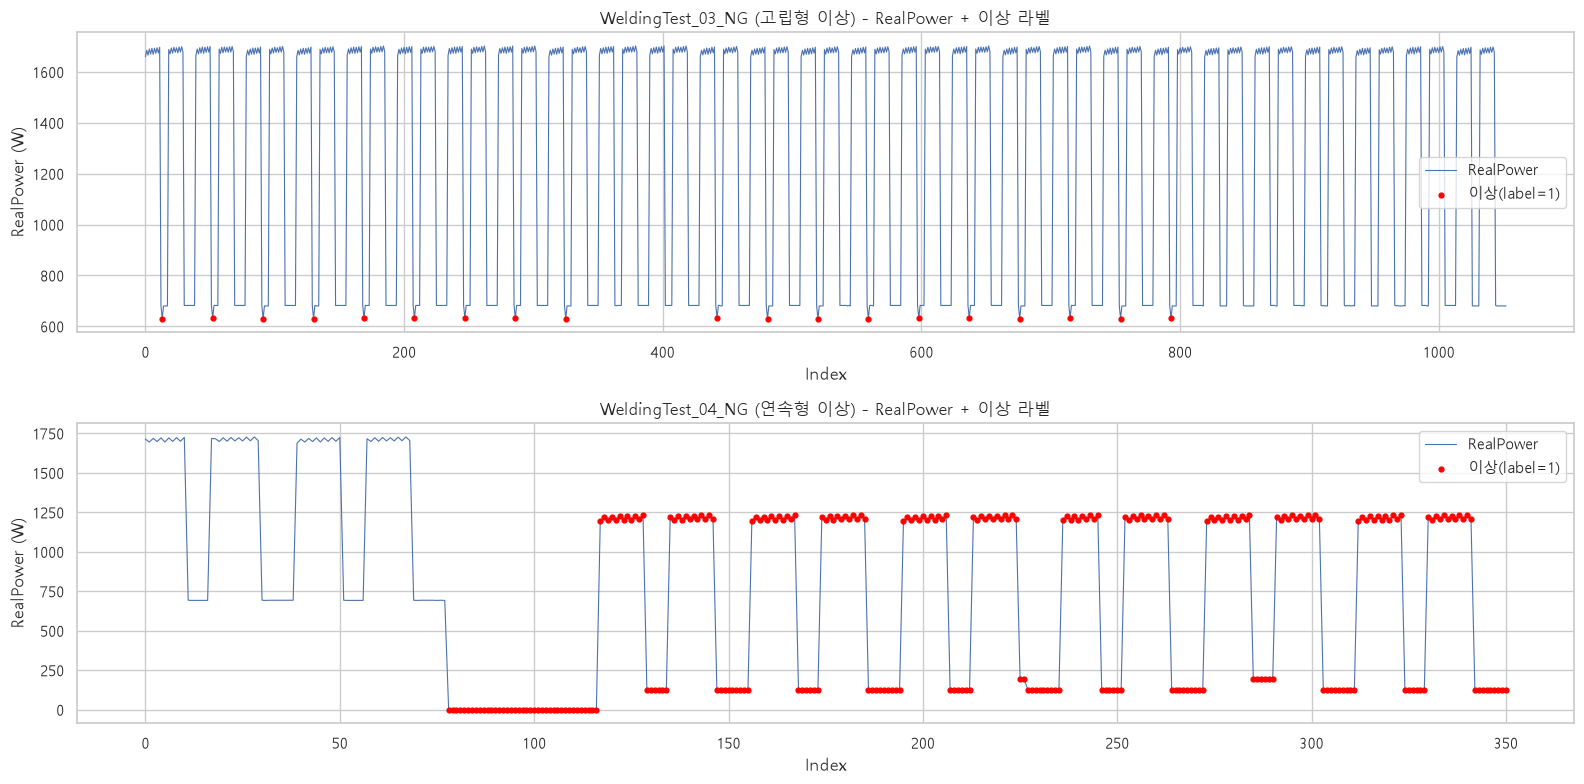

In [18]:
def plot_with_labels(name, df, label_df, ax):
    ax.plot(df["RealPower"].values, linewidth=0.8, color="#4C72B0", label="RealPower")
    anomaly_idx = label_df.index[label_df["label"] == 1]
    if len(anomaly_idx) > 0:
        ax.scatter(anomaly_idx, df["RealPower"].values[anomaly_idx],
                    color="red", s=12, zorder=5, label="이상(label=1)")
    ax.set_title(f"{name} - RealPower + 이상 라벨")
    ax.set_xlabel("Index")
    ax.set_ylabel("RealPower (W)")
    ax.legend()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
plot_with_labels("WeldingTest_03_NG (고립형 이상)", datasets["test03_NG"], labels["test03_NG"], axes[0])
plot_with_labels("WeldingTest_04_NG (연속형 이상)", datasets["test04_NG"], labels["test04_NG"], axes[1])
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/ng_anomaly_labels.png", dpi=120)
plt.show()

In [19]:
for name in ["test03_NG", "test04_NG"]:
    n_anom = (labels[name]["label"] == 1).sum()
    total = len(labels[name])
    print(f"{name}: 이상 라벨 {n_anom} / 전체 {total} ({100*n_anom/total:.2f}%)")

test03_NG: 이상 라벨 19 / 전체 1053 (1.80%)
test04_NG: 이상 라벨 273 / 전체 351 (77.78%)


## 9. 요약

- 학습 데이터(`Training_Data.csv`)는 결측치가 없고, `SetFrequency`/`SetDuty`가 상수값이라 분석 시 제외 대상입니다.
- `RealPower`는 `SetPower`(38%/82%/83%)에 따라 서로 다른 값 구간으로 갈라지는 다봉(multi-modal) 분포를 보입니다.
- `WeldingTest_01_OK`, `WeldingTest_02_OK`는 학습 데이터와 유사한 분포를 보이는 정상 데이터입니다.
- `WeldingTest_03_NG`는 고립된 시점에서 RealPower가 정상 범위를 크게 벗어나는 스파이크성 이상을,
  `WeldingTest_04_NG`는 특정 시점 이후 연속 구간 전체가 정상 범위를 벗어나는 이상을 보입니다.
- 이러한 관찰은 가이드북에서 제시한 분석 전략(고립형 이상 → N-HiTS, 연속형 이상 → 통계분포 Z-score)과 일치합니다.

### 다음 단계
- N-HiTS 기반 시계열 예측 모델 학습 노트북 작성
- 통계분포(Z-score) 기반 이상탐지 노트북 작성
- `src/`에 전처리/이상치탐지/평가 함수를 모듈화하여 재사용
